# SHAP API

A guided exploration of SHAP (SHapley Additive exPlanations):
- **Explainer**: wraps a trained ML model and computes Shapley values
- **Explanation**: holds SHAP values, baseline prediction, and feature data
- **Plots**: visualize feature contributions locally (per prediction) and globally

## Imports and Setup

In [40]:
%load_ext autoreload
%autoreload 2

import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

# TODO(ai_gp): Use import ... instead of from import
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import helpers.hdbg as hdbg
import helpers.hintrospection as hintros
import helpers.hnotebook as hnotebook

hdbg.init_logger(verbosity=logging.INFO)
_LOG = logging.getLogger(__name__)
hnotebook.config_notebook()

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

INFO  > cmd='/opt/venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-e30c7a25-5152-4b1f-96fc-83f236f291da.json'


## Library Overview

- **What problem it solves**:
  - Modern ML models (tree ensembles, neural nets) are accurate but opaque
  - SHAP answers "why did the model predict X?" for any single prediction
  - Decomposes predictions into per-feature contributions grounded in game
    theory (Shapley values from cooperative game theory)

- **Key abstraction**:
  - Every prediction = baseline + sum of per-feature SHAP values
  - Shapley values satisfy consistency, dummy, and efficiency axioms (no other
    attribution satisfying all three exists)

- **Mental model**:
  ```
  model: X -> prediction
  Explainer(model, background) -> configured explainer
  explainer(X) -> Explanation
  Explanation.values       shape (n_samples, n_features): per-feature SHAP
  Explanation.base_values  shape (n_samples,): E[model(X)] baseline
  Explanation.data         shape (n_samples, n_features): original feature values
  prediction[i] = base_values[i] + values[i].sum()
  ```

- **Key classes**:
  - `shap.Explainer`: auto-selects best algorithm for the model type
  - `shap.TreeExplainer`: fast and exact for tree-based models
  - `shap.LinearExplainer`: exact for linear models
  - `shap.KernelExplainer`: model-agnostic, works with any callable
  - `shap.Explanation`: result object (values, base_values, data)

# Part 1: Toy Data Setup

## Cell 1.1: Create a toy regression dataset

**Goal**:
- Build the minimal dataset needed to explore all SHAP primitives
- Use regression (not classification) to keep SHAP values 2D and easy to inspect

In [3]:
# Four named features, 30 samples, pure regression target.
np.random.seed(42)
X, y = make_regression(
    n_samples=30,
    n_features=4,
    n_informative=3,
    noise=10.0,
    random_state=42,
)
X_df = pd.DataFrame(X, columns=["age", "income", "debt", "employment"])
y_s = pd.Series(y, name="target")

print("X_df.shape=", X_df.shape)
print("y_s.shape=", y_s.shape)
display(X_df.head(3))

X_df.shape= (30, 4)
y_s.shape= (30,)


,age,income,debt,employment
0,-1.150994,0.375698,0.110923,-0.544383
1,1.477894,-0.518270,0.357113,-0.219672
2,-1.106335,-1.196207,-0.185659,-0.479174


In [ ]:
# TODO(ai_gp): Perform some analysis of the data set (e.g., correlations between features, X and Y, ...)

## Cell 1.2: Train models (one per explainer type)

**Goal**:
- Prepare one tree model, one linear model, and one black-box model
- Use small models to make SHAP computation fast

In [4]:
# Tree model for TreeExplainer.
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_df, y_s)
print("tree_model=", tree_model)

tree_model= DecisionTreeRegressor(max_depth=3, random_state=42)


In [5]:
# Linear model for LinearExplainer.
linear_model = LinearRegression()
linear_model.fit(X_df, y_s)
print("linear_model=", linear_model)

linear_model= LinearRegression()


In [6]:
# Random forest as a "black box" model for KernelExplainer.
rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_df, y_s)
print("rf_model=", rf_model)

rf_model= RandomForestRegressor(n_estimators=10, random_state=42)


In [41]:
# TODO(ai_gp): For each model compute performance in sample and out of sample.

# Part 2: Primitive 1 - The Explainer

## Cell 2.1: Construct a TreeExplainer

**Mental model**:
- `TreeExplainer` wraps a trained tree-based model
- It traverses the tree structure to compute exact Shapley values in polynomial
  time (no sampling needed)
- No background data required: the tree encodes the full conditional distribution

In [42]:
# Smallest possible construction: just the model.
tree_explainer = shap.TreeExplainer(tree_model)
print("type(tree_explainer)=", type(tree_explainer))

type(tree_explainer)= <class 'shap.explainers._tree.TreeExplainer'>


## Cell 2.2: Inspect the TreeExplainer

In [44]:
# expected_value is E[model(X)], the global baseline.
print("tree_explainer.expected_value=", tree_explainer.expected_value)
print("mean of y (approx baseline)=", round(y_s.mean(), 4))

# TODO(ai_gp): Explain the results and what they mean.

tree_explainer.expected_value= [-12.99654379]
mean of y (approx baseline)= -12.9965


In [43]:
# Public interface of the explainer.
# TODO(ai_gp): Improve print_public_methods to create a dataframe with function, explanation, signature
hintros.print_public_methods(tree_explainer, use_markdown=True)

- `assert_additivity(phi: 'npt.NDArray[Any] | list[npt.NDArray[Any]]', model_output: 'npt.NDArray[Any]') -> 'None'`
- `explain_row(*row_args: 'Any', max_evals: "int | Literal['auto']", main_effects: 'bool', error_bounds: 'bool', outputs: 'Any', silent: 'bool', **kwargs: 'Any') -> 'dict[str, Any]'` — Explains a single row and returns the tuple (row_values, row_expected_values, row_mask_shapes, main_effects).
- `link(x: 'npt.NDArray[Any] | float') -> 'npt.NDArray[Any] | float'` — A no-op link function.
- `load(in_file: 'Any', model_loader: 'Callable[..., Any] | None' = None, masker_loader: 'Callable[..., Any] | None' = None, instantiate: 'bool' = True) -> 'Explainer | dict[str, Any]'` — Load an Explainer from the given file stream.
- `save(out_file: 'Any', model_saver: 'str | Callable[..., Any]' = '.save', masker_saver: 'str | Callable[..., Any]' = '.save') -> 'None'` — Write the explainer to the given file stream.
- `shap_interaction_values(X: 'npt.NDArray[Any] | pd.DataFrame | Any', y:

## Cell 2.3: Construct a LinearExplainer

**Mental model**:
- `LinearExplainer` wraps a linear model together with background data
- Background data captures feature means and covariances used to compute
  conditional expectations

In [10]:
# LinearExplainer needs the model and background data.
linear_explainer = shap.LinearExplainer(linear_model, X_df)
print("type(linear_explainer)=", type(linear_explainer))
print("linear_explainer.expected_value=", linear_explainer.expected_value)

type(linear_explainer)= <class 'shap.explainers._linear.LinearExplainer'>
linear_explainer.expected_value= -12.996543788805079


## Cell 2.4: Construct a KernelExplainer (model-agnostic)

**Mental model**:
- `KernelExplainer` works with any callable - it treats the model as a black box
- Approximates Shapley values by sampling perturbations of the input
- Slower than TreeExplainer but works with any model (sklearn, TensorFlow, etc.)
- Background data should be a small summary of the training distribution

In [11]:
# Summarize background data with k-means to speed up sampling.
background = shap.kmeans(X_df, k=5)
print("type(background)=", type(background))
print("background.data.shape=", background.data.shape)

type(background)= <class 'shap.utils._legacy.DenseData'>
background.data.shape= (5, 4)


In [12]:
# Wrap rf_model.predict as a callable.
kernel_explainer = shap.KernelExplainer(rf_model.predict, background)
print("type(kernel_explainer)=", type(kernel_explainer))
print("kernel_explainer.expected_value=", kernel_explainer.expected_value)

type(kernel_explainer)= <class 'shap.explainers._kernel.KernelExplainer'>
kernel_explainer.expected_value= -12.54348980387191


## Cell 2.5: Construct shap.Explainer (auto-dispatch)

**Mental model**:
- `shap.Explainer` inspects the model type and auto-selects the best algorithm
- If the model is a tree: uses TreeExplainer internally
- If linear: uses LinearExplainer
- Otherwise: falls back to PermutationExplainer or KernelExplainer

In [13]:
# Auto-dispatch based on model type.
auto_explainer = shap.Explainer(tree_model, X_df)
print("type(auto_explainer)=", type(auto_explainer))
# Internally dispatches to TreeExplainer for a DecisionTreeRegressor.

type(auto_explainer)= <class 'shap.explainers._tree.TreeExplainer'>


# Part 3: Primitive 2 - The Explanation Object

## Cell 3.1: Compute SHAP values (get an Explanation)

**Mental model**:
- Calling `explainer(X)` returns an `Explanation` object
- This bundles SHAP values, baseline, and original data into one structure

In [14]:
# Compute SHAP values for all 30 samples.
explanation = tree_explainer(X_df)
print("type(explanation)=", type(explanation))

type(explanation)= <class 'shap._explanation.Explanation'>


## Cell 3.2: Inspect Explanation.values

In [15]:
# .values: SHAP contribution of each feature for each sample.
print("type(explanation.values)=", type(explanation.values))
print("explanation.values.shape=", explanation.values.shape)
# Rows = samples, columns = features.
values_df = pd.DataFrame(explanation.values, columns=X_df.columns)
display(values_df.head(3))

type(explanation.values)= <class 'numpy.ndarray'>
explanation.values.shape= (30, 4)


,age,income,debt,employment
0,-75.845605,0.0,38.588105,1.552185
1,31.730777,0.0,28.038606,2.085164
2,-75.845605,0.0,38.588105,1.552185


## Cell 3.3: Inspect Explanation.base_values

In [16]:
# .base_values: model's expected output (same for all samples).
print("explanation.base_values.shape=", explanation.base_values.shape)
print("explanation.base_values[0]=", round(explanation.base_values[0], 4))
print(
    "all identical?",
    np.allclose(explanation.base_values, explanation.base_values[0]),
)

explanation.base_values.shape= (30,)
explanation.base_values[0]= -12.9965
all identical? True


## Cell 3.4: Inspect Explanation.data

In [17]:
# .data: the original feature values passed to the explainer.
print("type(explanation.data)=", type(explanation.data))
print("explanation.data.shape=", explanation.data.shape)
display(pd.DataFrame(explanation.data, columns=X_df.columns).head(3))

type(explanation.data)= <class 'numpy.ndarray'>
explanation.data.shape= (30, 4)


,age,income,debt,employment
0,-1.150994,0.375698,0.110923,-0.544383
1,1.477894,-0.518270,0.357113,-0.219672
2,-1.106335,-1.196207,-0.185659,-0.479174


## Cell 3.5: Verify the additive decomposition

**Key invariant**:
- `prediction[i] = base_value + sum(shap_values[i])`
- This always holds exactly for TreeExplainer (and LinearExplainer)

In [18]:
# Verify for sample index 0.
idx = 0
model_pred = tree_model.predict(X_df.iloc[[idx]])[0]
shap_sum = explanation.base_values[idx] + explanation.values[idx].sum()
print("model_pred=", round(model_pred, 6))
print("base + sum(shap)=", round(shap_sum, 6))
print("match?", np.isclose(model_pred, shap_sum))

model_pred= -48.701858
base + sum(shap)= -48.701858
match? True


## Cell 3.6: Index the Explanation object

- `explanation[i]` selects sample i (returns Explanation with shape (n_features,))
- `explanation[:, j]` selects feature j across all samples (shape (n_samples,))
- `explanation[i, j]` selects a single SHAP scalar

In [19]:
# Single sample.
sample_exp = explanation[0]
print("type(sample_exp)=", type(sample_exp))
print("sample_exp.values=", sample_exp.values)
print("sample_exp.base_values=", sample_exp.base_values)

type(sample_exp)= <class 'shap._explanation.Explanation'>
sample_exp.values= [-75.84560473   0.          38.58810506   1.55218532]
sample_exp.base_values= -12.996543788805083


In [20]:
# Single feature across all samples.
income_exp = explanation[:, "income"]
print("type(income_exp)=", type(income_exp))
print("income_exp.values.shape=", income_exp.values.shape)

type(income_exp)= <class 'shap._explanation.Explanation'>
income_exp.values.shape= (30,)


In [21]:
# Single (sample, feature) scalar.
scalar_exp = explanation[0, "income"]
print("explanation[0, 'income'].values=", scalar_exp.values)

explanation[0, 'income'].values= 0.0


# Part 4: Primitive 3 - SHAP Plots

## Cell 4.1: Waterfall plot (single prediction)

**Goal**:
- See how each feature pushes prediction above or below the baseline for one sample
- Start at `E[f(X)]` (bottom), end at `f(x)` (model output)

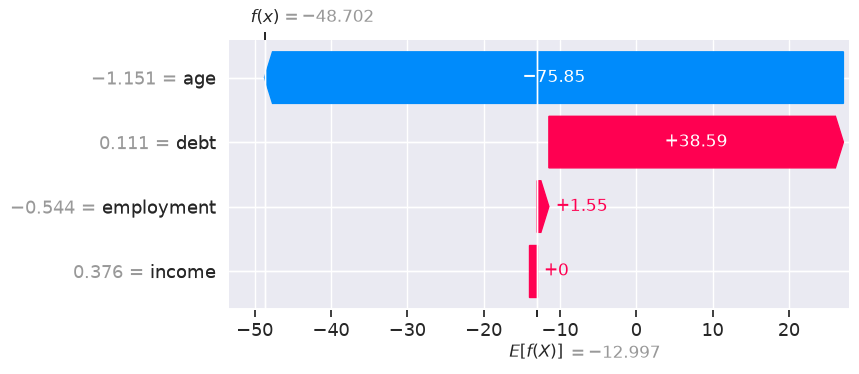

In [22]:
# Waterfall plot for sample 0: shows individual feature contributions.
shap.plots.waterfall(explanation[0])
plt.close("all")

**Key observations**:
- Each horizontal bar = one feature's SHAP contribution
- Red: feature pushes prediction up
- Blue: feature pushes prediction down
- Total = base_value + signed sum of all bars = model output

## Cell 4.2: Bar plot (global feature importance)

**Goal**:
- Rank features by their average absolute SHAP value across all samples
- This is the global view: which features matter most overall?

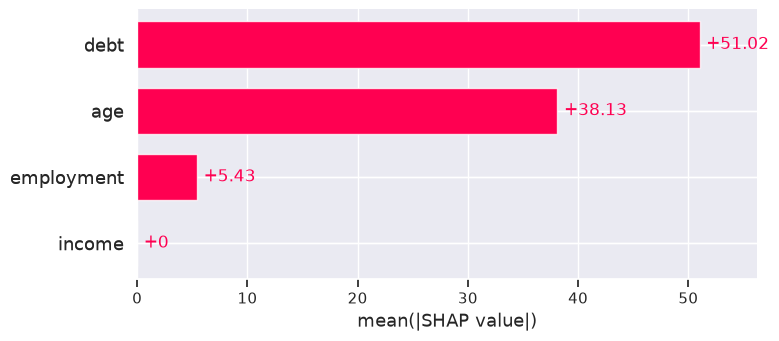

In [23]:
# Bar plot: mean |SHAP value| per feature across all samples.
shap.plots.bar(explanation)
plt.close("all")

**Key observations**:
- Bar length = mean(|SHAP value|) averaged across 30 samples
- Longer bar = feature matters more globally
- Does not show direction (sign), only magnitude

## Cell 4.3: Beeswarm plot (global distribution of SHAP values)

**Goal**:
- Show the distribution of SHAP values per feature across all samples
- Color encodes the feature value (red = high, blue = low)

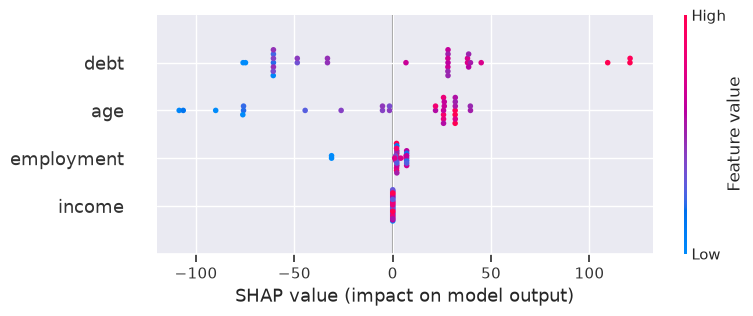

In [24]:
# Beeswarm: one dot per (sample, feature), color = feature value.
shap.plots.beeswarm(explanation)
plt.close("all")

**Key observations**:
- Each dot = one sample's SHAP value for a given feature
- Horizontal spread = range of SHAP contributions for that feature
- Red dots with high SHAP -> high feature value increases the prediction
- Blue dots with low SHAP -> low feature value decreases the prediction

## Cell 4.4: Scatter plot (feature dependence)

**Goal**:
- See how a single feature's value relates to its SHAP contribution
- Reveals linear, monotonic, or threshold-based effects

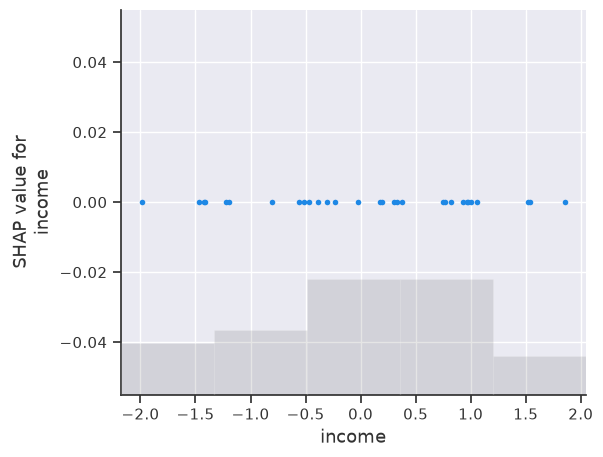

In [25]:
# Scatter: x = feature value, y = SHAP contribution for "income".
shap.plots.scatter(explanation[:, "income"])
plt.close("all")

**Key observations**:
- x-axis: raw feature value (income)
- y-axis: SHAP contribution for income
- A diagonal line -> monotonic effect; an S-curve -> threshold or saturation

# Part 5: Composition Examples

## Cell 5.1: End-to-end with LinearExplainer

Verify that LinearExplainer also satisfies the additive decomposition.

In [26]:
# Compute SHAP values with linear explainer.
linear_explanation = linear_explainer(X_df)
print("linear_explanation.values.shape=", linear_explanation.values.shape)

linear_explanation.values.shape= (30, 4)


In [27]:
# Verify additivity for linear model.
pred_lin = linear_model.predict(X_df.iloc[[0]])[0]
shap_sum_lin = (
    linear_explanation.base_values[0] + linear_explanation.values[0].sum()
)
print("linear model pred=", round(pred_lin, 6))
print("base + sum(shap)=", round(shap_sum_lin, 6))
print("match?", np.isclose(pred_lin, shap_sum_lin))

linear model pred= -44.844696
base + sum(shap)= -44.844696
match? True


## Cell 5.2: Compare SHAP importances across models

Different model types may rank features differently even on the same data.

In [28]:
# Build a comparison DataFrame: tree vs linear mean absolute SHAP.
tree_importance = pd.Series(
    np.abs(explanation.values).mean(axis=0),
    index=X_df.columns,
    name="tree",
)
linear_importance = pd.Series(
    np.abs(linear_explanation.values).mean(axis=0),
    index=X_df.columns,
    name="linear",
)
importance_df = pd.DataFrame([tree_importance, linear_importance]).T
display(importance_df.sort_values("tree", ascending=False))

,tree,linear
debt,51.018754,49.928186
age,38.125740,29.392221
employment,5.431547,13.112381
income,0.000000,0.954521


## Cell 5.3: Local explanation for a specific sample

Build a per-sample breakdown table of feature values and their SHAP contributions.

In [29]:
# Table: feature value, SHAP value, and absolute SHAP for sample 5.
sample_idx = 5
local_df = pd.DataFrame(
    {
        "feature_value": X_df.iloc[sample_idx].values,
        "shap_value": explanation.values[sample_idx],
        "abs_shap": np.abs(explanation.values[sample_idx]),
    },
    index=X_df.columns,
).sort_values("abs_shap", ascending=False)
display(local_df)

,feature_value,shap_value,abs_shap
debt,-0.719844,-48.528767,48.528767
employment,-1.478522,-31.098351,31.098351
age,-0.460639,-5.204063,5.204063
income,1.057122,0.000000,0.000000


## Cell 5.4: Global importance as a sorted DataFrame

In [30]:
# Global feature ranking by mean absolute SHAP.
global_importance_df = pd.DataFrame(
    {
        "feature": X_df.columns,
        "mean_abs_shap": np.abs(explanation.values).mean(axis=0),
        "mean_shap": explanation.values.mean(axis=0),
    }
).sort_values("mean_abs_shap", ascending=False)
display(global_importance_df)

,feature,mean_abs_shap,mean_shap
2,debt,51.018754,1.748278
0,age,38.125740,-3.033378
3,employment,5.431547,1.285100
1,income,0.000000,0.000000


# Part 6: API Patterns

## Cell 6.1: Fit-explain pattern

The standard SHAP workflow: train model -> create explainer -> call on data.

In [31]:
# Train, wrap, explain in three lines.
m = DecisionTreeRegressor(max_depth=2, random_state=0)
m.fit(X_df, y_s)
expl = shap.TreeExplainer(m)
expl_vals = expl(X_df)
print("expl_vals.values.shape=", expl_vals.values.shape)

expl_vals.values.shape= (30, 4)


## Cell 6.2: Slicing and indexing pattern

In [32]:
# Slice by sample index -> one sample's explanation.
s3 = explanation[3]
print("explanation[3].values=", s3.values)

explanation[3].values= [31.79746616  0.         28.10529563  1.9517849 ]


In [33]:
# Slice by feature name -> all samples for that feature.
debt_shap = explanation[:, "debt"]
print("explanation[:, 'debt'].values.shape=", debt_shap.values.shape)

explanation[:, 'debt'].values.shape= (30,)


In [34]:
# Slice by both -> scalar SHAP value.
scalar_val = explanation[3, "income"]
print("explanation[3, 'income'].values=", scalar_val.values)

explanation[3, 'income'].values= 0.0


## Cell 6.3: Background data summary with shap.kmeans

In [35]:
# Summarize X_df into k representative rows for use in KernelExplainer.
bg_3 = shap.kmeans(X_df, k=3)
print("type(bg_3)=", type(bg_3))
print("bg_3.data.shape=", bg_3.data.shape)
display(pd.DataFrame(bg_3.data, columns=X_df.columns))

type(bg_3)= <class 'shap.utils._legacy.DenseData'>
bg_3.data.shape= (3, 4)


,age,income,debt,employment
0,0.647689,0.821903,-0.185659,-0.469474
1,-0.460639,-1.196207,-0.719844,-0.161286
2,-0.908024,0.174578,0.611676,0.087047


# Part 7: Interactive Exploration

## Cell 7.1: What does the Explanation object expose?

In [36]:
# Inspect public interface of the Explanation object.
hintros.print_public_methods(explanation, use_markdown=True)

- `cohorts(cohorts: 'int | list[int] | tuple[int] | np.ndarray') -> 'Cohorts'` — Split this explanation into several cohorts.
- `hclust(metric: 'str' = 'sqeuclidean', axis: 'Literal[0, 1]' = 0) -> 'npt.NDArray[np.int64]'` — Computes an optimal leaf ordering sort order using hclustering.
- `hstack(other: 'Explanation') -> 'Explanation'` — Stack two explanations column-wise.
- `max(axis: 'int') -> 'Explanation'` — Numpy-style max function.
- `mean(axis: 'int') -> 'Explanation'` — Numpy-style mean function.
- `min(axis: 'int') -> 'Explanation'` — Numpy-style min function.
- `percentile(q: 'float', axis: 'int | None' = None) -> 'Explanation'`
- `sample(max_samples: 'int', replace: 'bool' = False, random_state: 'int' = 0) -> 'Explanation'` — Randomly samples the instances (rows) of the Explanation object.
- `sum(axis: 'int | None' = None, grouping: 'dict[str, str] | None' = None) -> 'Explanation'` — Numpy-style sum function.


## Cell 7.2: What happens if you use a different sample?

Each sample gets its own SHAP values - waterfall plots differ by sample.

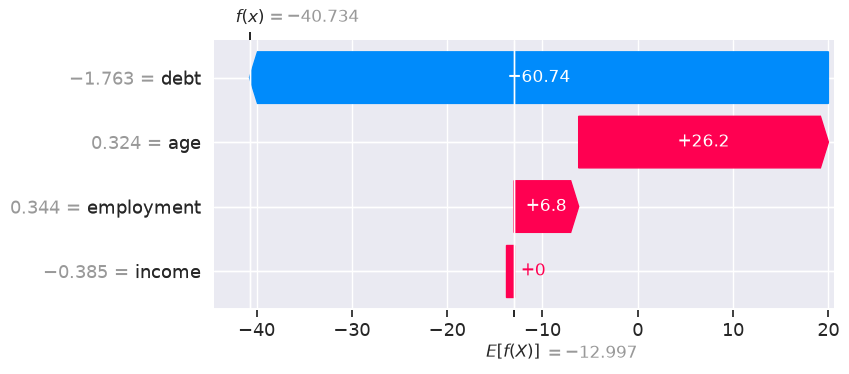

In [37]:
# Waterfall for sample 10 vs sample 0.
shap.plots.waterfall(explanation[10])
plt.close("all")

In [38]:
# Build a comparison: SHAP values for sample 0 vs sample 10.
compare_df = pd.DataFrame(
    {
        "sample_0": explanation[0].values,
        "sample_10": explanation[10].values,
    },
    index=X_df.columns,
)
display(compare_df)

,sample_0,sample_10
age,-75.845605,26.200602
income,0.000000,0.000000
debt,38.588105,-60.736821
employment,1.552185,6.799026


## Cell 7.3: What is the sign of SHAP values?

Positive SHAP -> feature increases prediction above baseline.
Negative SHAP -> feature decreases prediction below baseline.

In [39]:
# Count positive vs negative SHAP values per feature across all samples.
sign_df = pd.DataFrame(
    {
        "n_positive": (explanation.values > 0).sum(axis=0),
        "n_negative": (explanation.values < 0).sum(axis=0),
    },
    index=X_df.columns,
)
display(sign_df)

,n_positive,n_negative
age,18,12
income,0,0
debt,17,13
employment,28,2


# Part 8: Summary

## Summary: The Mental Model

- **`Explainer` variants**: `TreeExplainer` (fastest, exact for trees),
  `LinearExplainer` (exact for linear models), `KernelExplainer` (any callable,
  slowest), and `shap.Explainer` (auto-dispatches) - all share the same
  interface: call with data, get back an `Explanation`
- **`Explanation` object**: the central data structure with three arrays:
  `.values` (SHAP contributions, shape `(n_samples, n_features)`),
  `.base_values` (model's average prediction), and `.data` (input feature values)
- **Additive decomposition**: `prediction[i] = base_values[i] + values[i].sum()`
  holds exactly - SHAP values are a faithful partition of each prediction
- **Plots**: `waterfall` for single-prediction breakdown, `bar` for global
  magnitude ranking, `beeswarm` for global distribution with direction, and
  `scatter` for feature-level dependence analysis